Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# MONAI 101 tutorial

In this tutorial, we will introduce how simple it can be to run an end-to-end classification pipeline with MONAI.

These steps will be included in this tutorial, and each of them will take only a few lines of code:
- Dataset download
- Data pre-processing
- Define a DenseNet-121 and run training
- Check the results on test dataset

This tutorial will use about 7GB of GPU memory and 10 minutes to run.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/2d_classification/monai_101.ipynb)

## Setup environment

In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[ignite, tqdm]"

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'


## Setup imports

In [ ]:
import logging
import numpy as np
import os
from pathlib import Path
import sys
import tempfile
import torch

from monai.apps import MedNISTDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.engines import SupervisedTrainer
from monai.handlers import StatsHandler
from monai.inferers import SimpleInferer
from monai.networks import eval_mode
from monai.networks.nets import densenet121
from monai.transforms import LoadImageD, EnsureChannelFirstD, ScaleIntensityD, Compose

print_config()

2024-11-08 11:14:57.868511: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 11:14:57.879594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1731060897.893174    8158 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1731060897.897186    8158 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-08 11:14:57.911027: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /home/<username>/miniconda3/envs/mri/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.0
Nibabel version: 5.0.0
scikit-image version: 0.24.0
scipy version: 1.14.1
Pillow version: 11.0.0
Tensorboard version: 2.18.0
gdown version: 5.2.0
TorchVision version: 0.20.1+cu124
tqdm version: 4.66.6
lmdb version: 1.5.1
psutil version: 6.1.0
pandas version: 2.2.3
einops version: 0.8.0
transformers version: 4.40.2
mlflow version: 2.17.2
pynrrd version: 1.0.0
clearml version: 1.16.5

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



## Setup data directory

You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [ ]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpmqkbxabc


## Use MONAI transforms to preprocess data

Medical images require specialized methods for I/O, preprocessing, and augmentation.
They often follow specific formats, are handled with specific protocols, and the data arrays are often high-dimensional.

In this example, we will perform image loading, data format verification, and intensity scaling with three `monai.transforms` listed below, and compose a pipeline ready to be used in next steps.

In [ ]:
transform = Compose(
    [
        LoadImageD(keys="image", image_only=True),
        EnsureChannelFirstD(keys="image"),
        ScaleIntensityD(keys="image"),
    ]
)

## Prepare datasets using MONAI Apps

We use `MedNISTDataset` in MONAI Apps to download a dataset to the specified directory and perform the pre-processing steps in the `monai.transforms` compose.

The MedNIST dataset was gathered from several sets from [TCIA](https://wiki.cancerimagingarchive.net/display/Public/Data+Usage+Policies+and+Restrictions),
[the RSNA Bone Age Challenge](http://rsnachallenges.cloudapp.net/competitions/4),
and [the NIH Chest X-ray dataset](https://cloud.google.com/healthcare/docs/resources/public-datasets/nih-chest).

The dataset is kindly made available by [Dr. Bradley J. Erickson M.D., Ph.D.](https://www.mayo.edu/research/labs/radiology-informatics/overview) (Department of Radiology, Mayo Clinic)
under the Creative Commons [CC BY-SA 4.0 license](https://creativecommons.org/licenses/by-sa/4.0/).

If you use the MedNIST dataset, please acknowledge the source. 

In [ ]:
dataset = MedNISTDataset(root_dir=root_dir, transform=transform, section="training", download=True)

MedNIST.tar.gz: 59.0MB [00:01, 34.0MB/s]                              

2024-11-08 11:15:01,673 - INFO - Downloaded: /tmp/tmpmqkbxabc/MedNIST.tar.gz


2024-11-08 11:15:01,789 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2024-11-08 11:15:01,790 - INFO - Writing into directory: /tmp/tmpmqkbxabc.


Loading dataset: 100%|██████████| 47164/47164 [00:40<00:00, 1158.56it/s]


## Define a network and a supervised trainer

To train a model that can perform the classification task, we will use the DenseNet-121 which is known for its performance on the ImageNet dataset.

For a typical supervised training workflow, MONAI provides `SupervisedTrainer` to define the hyper-parameters.

In [ ]:
max_epochs = 5
model = densenet121(spatial_dims=2, in_channels=1, out_channels=6).to("cuda:0")

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
trainer = SupervisedTrainer(
    device=torch.device("cuda:0"),
    max_epochs=max_epochs,
    train_data_loader=DataLoader(dataset, batch_size=512, shuffle=True, num_workers=4),
    network=model,
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-5),
    loss_function=torch.nn.CrossEntropyLoss(),
    inferer=SimpleInferer(),
    train_handlers=StatsHandler(),
)

In [ ]:
len(dataset)

47164

In [ ]:
next(iter(DataLoader(dataset)))['image'].shape

torch.Size([1, 1, 64, 64])

## Run the training

In [ ]:
trainer.run()

INFO:ignite.engine.engine.SupervisedTrainer:Engine run resuming from iteration 0, epoch 0 until 5 epochs
2024-11-08 11:18:02,209 - INFO - Epoch: 1/5, Iter: 1/93 -- label: 3.0000 loss: 1.8158 
2024-11-08 11:18:02,397 - INFO - Epoch: 1/5, Iter: 2/93 -- label: 0.0000 loss: 1.7667 


ignoring non-scalar output in StatsHandler, make sure `output_transform(engine.state.output)` returns a scalar or dictionary of key and scalar pairs to avoid this warning. image:<class 'monai.data.meta_tensor.MetaTensor'>
ignoring non-scalar output in StatsHandler, make sure `output_transform(engine.state.output)` returns a scalar or dictionary of key and scalar pairs to avoid this warning. pred:<class 'monai.data.meta_tensor.MetaTensor'>


2024-11-08 11:18:02,579 - INFO - Epoch: 1/5, Iter: 3/93 -- label: 5.0000 loss: 1.7375 
2024-11-08 11:18:02,746 - INFO - Epoch: 1/5, Iter: 4/93 -- label: 4.0000 loss: 1.7052 
2024-11-08 11:18:02,916 - INFO - Epoch: 1/5, Iter: 5/93 -- label: 4.0000 loss: 1.6726 
2024-11-08 11:18:03,084 - INFO - Epoch: 1/5, Iter: 6/93 -- label: 3.0000 loss: 1.6461 
2024-11-08 11:18:03,255 - INFO - Epoch: 1/5, Iter: 7/93 -- label: 2.0000 loss: 1.6321 
2024-11-08 11:18:03,429 - INFO - Epoch: 1/5, Iter: 8/93 -- label: 1.0000 loss: 1.6093 
2024-11-08 11:18:03,599 - INFO - Epoch: 1/5, Iter: 9/93 -- label: 4.0000 loss: 1.5616 
2024-11-08 11:18:03,791 - INFO - Epoch: 1/5, Iter: 10/93 -- label: 5.0000 loss: 1.5380 
2024-11-08 11:18:03,967 - INFO - Epoch: 1/5, Iter: 11/93 -- label: 2.0000 loss: 1.5053 
2024-11-08 11:18:04,161 - INFO - Epoch: 1/5, Iter: 12/93 -- label: 4.0000 loss: 1.4839 
2024-11-08 11:18:04,344 - INFO - Epoch: 1/5, Iter: 13/93 -- label: 4.0000 loss: 1.4508 
2024-11-08 11:18:04,522 - INFO - Epoch:

## Check the prediction on the test dataset

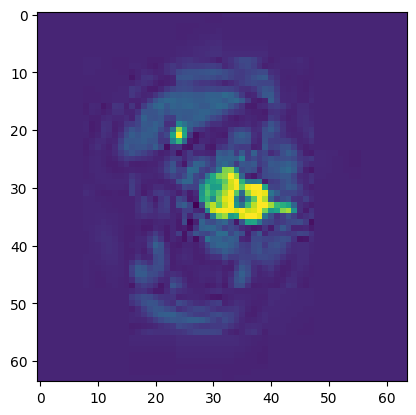

Class prediction is AbdomenCT. Ground-truth: AbdomenCT


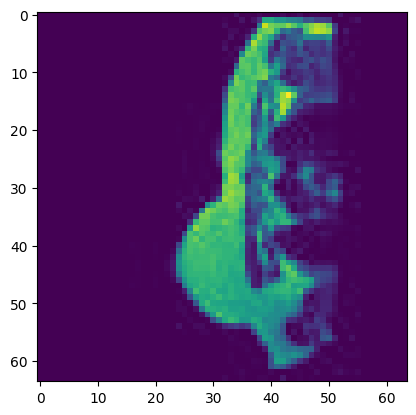

Class prediction is BreastMRI. Ground-truth: BreastMRI


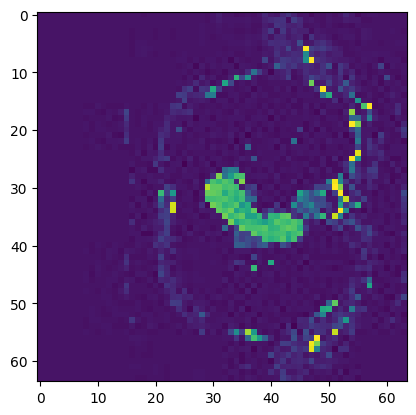

Class prediction is ChestCT. Ground-truth: ChestCT


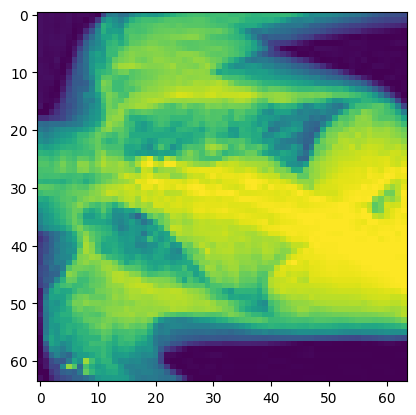

Class prediction is CXR. Ground-truth: CXR


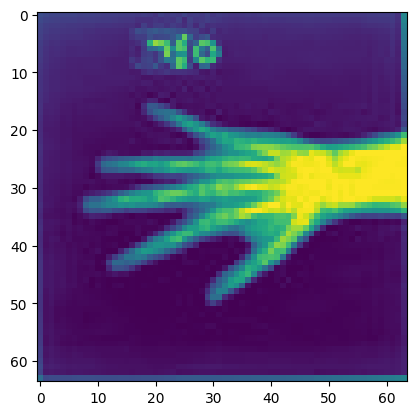

Class prediction is Hand. Ground-truth: Hand


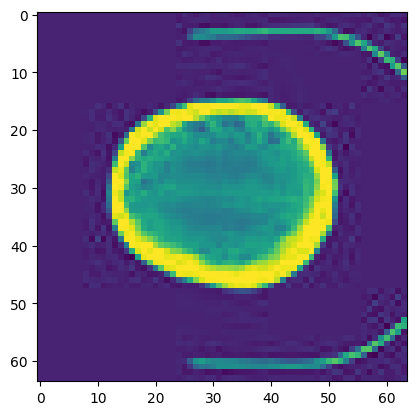

Class prediction is HeadCT. Ground-truth: HeadCT


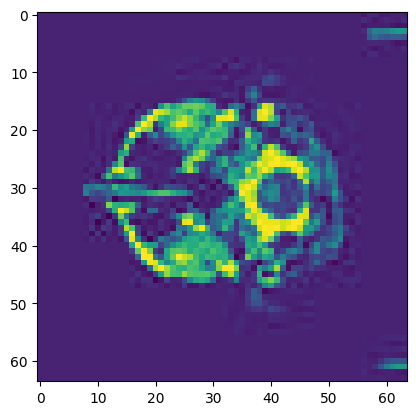

Class prediction is HeadCT. Ground-truth: HeadCT


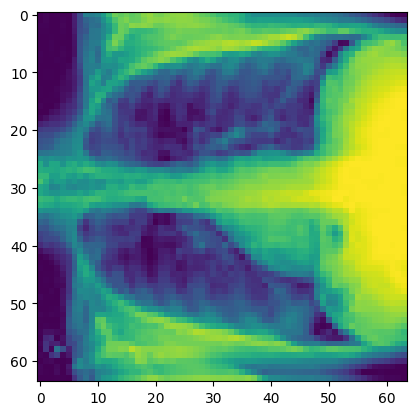

Class prediction is CXR. Ground-truth: CXR


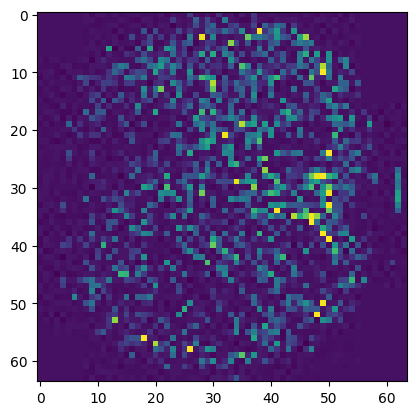

Class prediction is ChestCT. Ground-truth: ChestCT


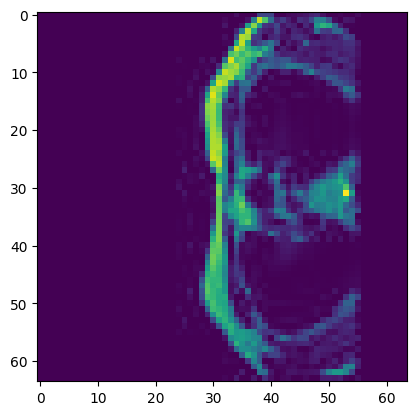

Class prediction is BreastMRI. Ground-truth: BreastMRI


In [ ]:
import matplotlib.pyplot as plt

dataset_dir = Path(root_dir, "MedNIST")
class_names = sorted(f"{x.name}" for x in dataset_dir.iterdir() if x.is_dir())
testdata = MedNISTDataset(root_dir=root_dir, transform=transform, section="test", download=False, runtime_cache=True)

max_items_to_print = 10
with eval_mode(model):
    for item in DataLoader(testdata, batch_size=1, num_workers=0):
        plt.imshow(item['image'].reshape(64,64))
        plt.show()
        prob = np.array(model(item["image"].to("cuda:0")).detach().to("cpu"))[0]
        pred = class_names[prob.argmax()]
        gt = item["class_name"][0]
        print(f"Class prediction is {pred}. Ground-truth: {gt}")
        max_items_to_print -= 1
        if max_items_to_print == 0:
            break